<a href="https://colab.research.google.com/github/Sanskruti-Gohil/Fake-Job-Posts-Detection/blob/main/Fake_Job_Post_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Random Forest Classifier

In [ ]:
pip install wordcloud

In [ ]:
pip install -U spacy

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from wordcloud import WordCloud
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English

In [ ]:
import csv
df = pd.read_csv(
    '/content/sample_data/fake_job_postings.csv',
    on_bad_lines='skip',
    quoting=csv.QUOTE_NONE,
    encoding='utf-8',
    engine='python'  # Use Python engine for more flexibility with messy data
)

In [ ]:
df.head()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
1,Marketing Intern,"""US",NY,"New York""",Marketing,NaN,"""We're Food52",and we've created a groundbreaking and award-winning cooking site. We support,connect,and celebrate home cooks,and give them everything they need in one place.We have a top editorial,business,and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests,and to offer them superb,highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali,Gwyneth Paltrow,and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP,and has been featured in the New York Times,NPR,Pando Daily,TechCrunch,and on the Today Show.We're located in Chelsea,"in New York City.""","""Food52",a fast-growing,James Beard Award-winning online food community and crowd-sourced and curated recipe hub,is currently interviewing full- and part-time unpaid interns to work in a small team of editors,executives,and developers in its New York City headquarters.Reproducing and/or repackaging existing Food52 content for a number of partner sites,such as Huffington Post,Yahoo,Buzzfeed,and more in their various content management systemsResearching blogs and websites for the Provisions by Food52 Affiliate ProgramAssisting in day-to-day affiliate program support,such as screening affiliates and assisting in any affiliate inquiriesSupporting with PR &amp; Events when neededHelping with office administrative work,such as filing,mailing,"and preparing for meetingsWorking with developers to document bugs and suggest improvements to the siteSupporting the marketing and executive staff""","""Experience with content management systems a major plus (any blogging counts!)Familiar with the Food52 editorial voice and aestheticLoves food",appreciates the importance of home cooking and cooking with the seasonsMeticulous editor,perfectionist,obsessive attention to detail,maddened by typos and broken links,delighted by finding and fixing themCheerful ...,Facebook,and PinterestLoves problem-solving and collab...,shopping,administrative support)Comfortable with the r...,"and working long hours""",NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0.0
3,Commissioning Machinery Assistant (CMA),"""US",IA,"Wever""",NaN,NaN,"""Valor Services provides Workforce Solutions that meet the needs of companies across the Private Sector",with a special focus on the Oil &amp; Gas Industry. Valor Services will be involved with you throughout every step of the hiring process and remain in contact with you all the way through the final step of signing of the employment contract with your new employer. Valor Services was founded with the vision of employing the unique skills,experiences,"and qualities of America’s finest veterans to provide Private Sector companies with precise and concerted value-added services – and America’s finest Veterans with an optimized career opportunity.We are eager to get the word out to veterans that there are ample opportunities for employment in the private sector and that you are the ideal candidates to fill those positions. Valor Services Your Success is Our Mission. ™ ""","""Our client",located in Houston,is actively seeking an experienced Commissioning Machinery Assistant that possesses strong supervisory skills and has an attention to detail. A strong dedication to safety is a must. The ideal candidate will execute all activities while complying with quality requirements and health,environmental,"and safety regulations.""","""Implement pre-commissioni

In [ ]:
df.shape

(15858, 19)

In [ ]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'country'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
salary_range,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0


In [ ]:
df['function'].value_counts()
stem=['Information Technology', 'Engineering', 'Data Analyst', 'Science', 'Buisness Analyst', 'Quality Assurance']
non_stem=['Sales','Customer Service', 'Marketing', 'Administrative', 'Design','Human Resources']
df_stem=df[df['function'].isin(stem)]
df_non_stem=df[df['function'].isin(non_stem)]
print(df_stem.shape)
print(df_non_stem.shape)

df_non_stem['fraudulent'].value_counts()

(35, 19)
(59, 19)


,count
fraudulent,
0.0,59


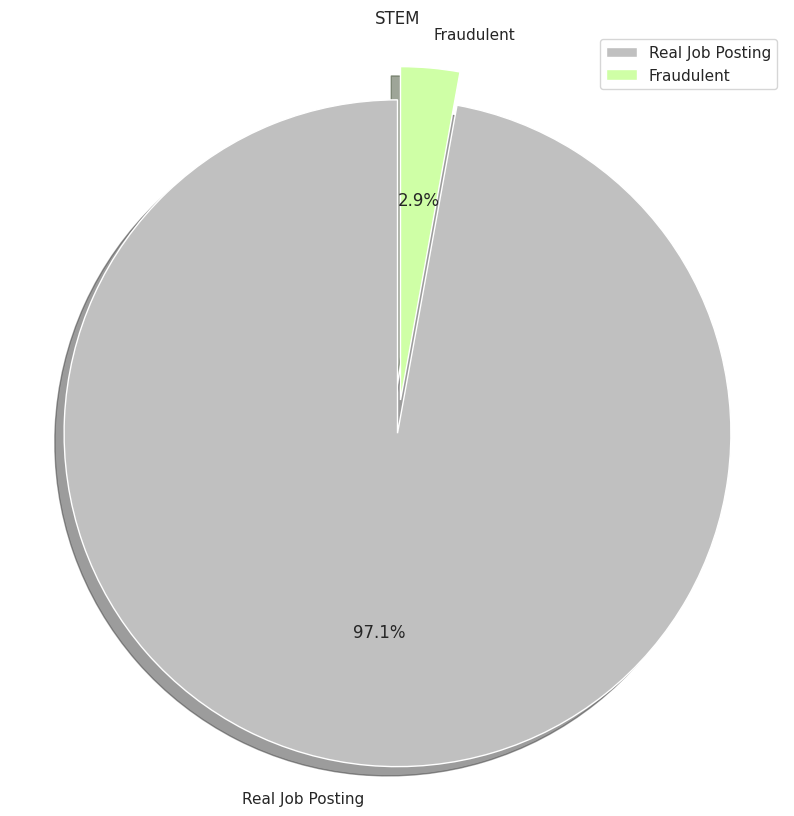

In [ ]:
import matplotlib.pyplot as plt

stem_zero = df_stem['fraudulent'].value_counts()[0]
stem_one = df_stem['fraudulent'].value_counts()[1]

labels = ['Real Job Posting', 'Fraudulent']
sizes = [stem_zero, stem_one]
explode = (0, 0.1)
colors = ['#C0C0C0', '#CFFFA6']

fig1, ax1 = plt.subplots(figsize=(10, 10))  # fixed typo here
ax1.pie(
    sizes,
    explode=explode,
    colors=colors,
    labels=labels,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('STEM')
plt.legend(loc='best')  # optional: specify legend position
plt.show()


In [ ]:
df.groupby('fraudulent')['fraudulent'].count()

,fraudulent
fraudulent,
0.0,148
1.0,5
,15705


In [ ]:
df_num=df[['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent','salary_range']]
df_cat=df[['title', 'location', 'company_profile', 'requirements', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']]

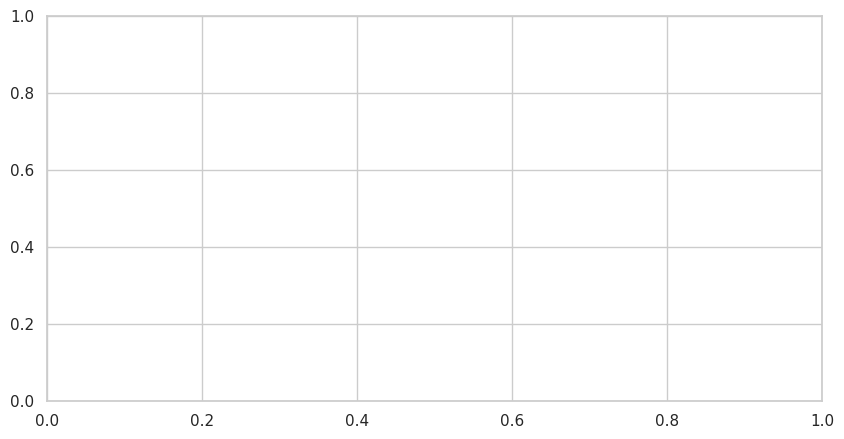

In [ ]:
# Checking outliers
plt.figure(figsize=[10,5])
sns.boxplot(data=df_num)
plt.show()

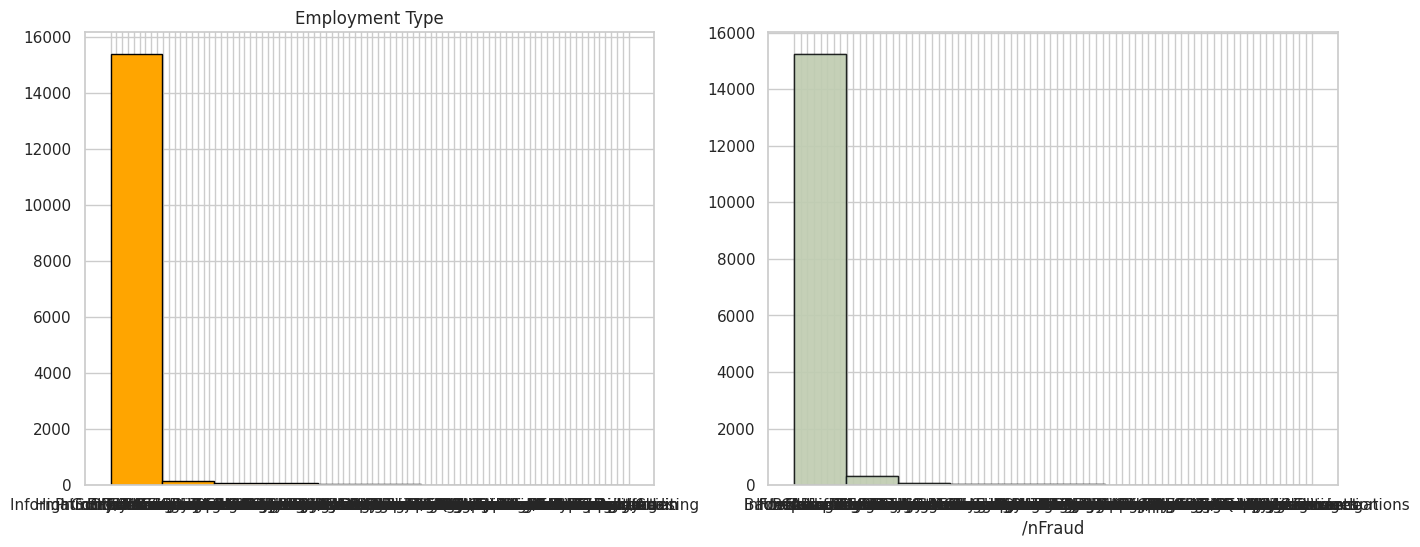

In [ ]:
# Plots to see the distribution of the continuous features individually

plt.figure(figsize=[25,20])
plt.subplot(3,3,1)
plt.hist(df.employment_type,color='orange',edgecolor='black')
plt.title('Employment Type')
plt.subplot(3,3,2)
plt.hist(df.required_experience,color='orange',edgecolor='black',alpha=0.7)
plt.xlabel('\nEmplyment Type')

plt.subplot(3,3,2)
plt.hist(df.required_experience,color='lightblue',edgecolor='black',alpha=0.7)
plt.xlabel('/nFraud')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Fill 'department' with mode
df['department'] = df['department'].fillna(df['department'].mode()[0])

# Fix 'fraudulent' column early to ensure it's numeric
df['fraudulent'] = pd.to_numeric(df['fraudulent'], errors='coerce').fillna(0).astype(int)

# Split column types correctly
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Ensure 'fraudulent' is excluded from X
if 'fraudulent' in num_cols:
    num_cols.remove('fraudulent')
if 'fraudulent' in cat_cols:
    cat_cols.remove('fraudulent')

# Define imputers
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="constant", fill_value="Missing")

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_imputer, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Define features and target
X = df.drop('fraudulent', axis=1)
y = df['fraudulent']

# Apply transformations
X_transformed = preprocessor.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.25, random_state=42)

# Output shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (11893, 9168)
X_test shape: (3965, 9168)
y_train shape: (11893,)
y_test shape: (3965,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest
model_rfm=RandomForestClassifier(random_state=42)
model_rfm.fit(X_train,y_train)
y_pred_rfm=model_rfm.predict(X_test)
rfc_accuracy=model_rfm.score(X_test,y_test)

In [ ]:
print(f"Fake Job Random Forest Model Classification Accuracy : {rfc_accuracy*100:.2f}%")

Fake Job Random Forest Model Classification Accuracy : 99.97%


In [ ]:
# Hyper parameter tuning
n_trees=[10,50,100,200,300]
for i in n_trees:
  ran_for=RandomForestClassifier(n_estimators=i)
  ran_for.fit(X_train,y_train)
  pred=ran_for.predict(X_test)

  print('n of trees: {}'.format(i))
  # Each time of prediction, the accuracy is measured
  correct_pred=0
  for j,k in zip(y_test,pred):
    if j==k:
      correct_pred+=1
  print('Correct predictions: {}'.format(correct_pred/len(y_test)*100))
  print('------------------------------------------------------------------')

n of trees: 10
Correct predictions: 99.97477931904162
------------------------------------------------------------------
n of trees: 50
Correct predictions: 99.97477931904162
------------------------------------------------------------------
n of trees: 100
Correct predictions: 99.97477931904162
------------------------------------------------------------------
n of trees: 200
Correct predictions: 99.97477931904162
------------------------------------------------------------------
n of trees: 300
Correct predictions: 99.97477931904162
------------------------------------------------------------------


<ipython-input-46-2d08a07975ca>:8: RuntimeWarning: divide by zero encountered in log
  log_val.append(np.log(i))


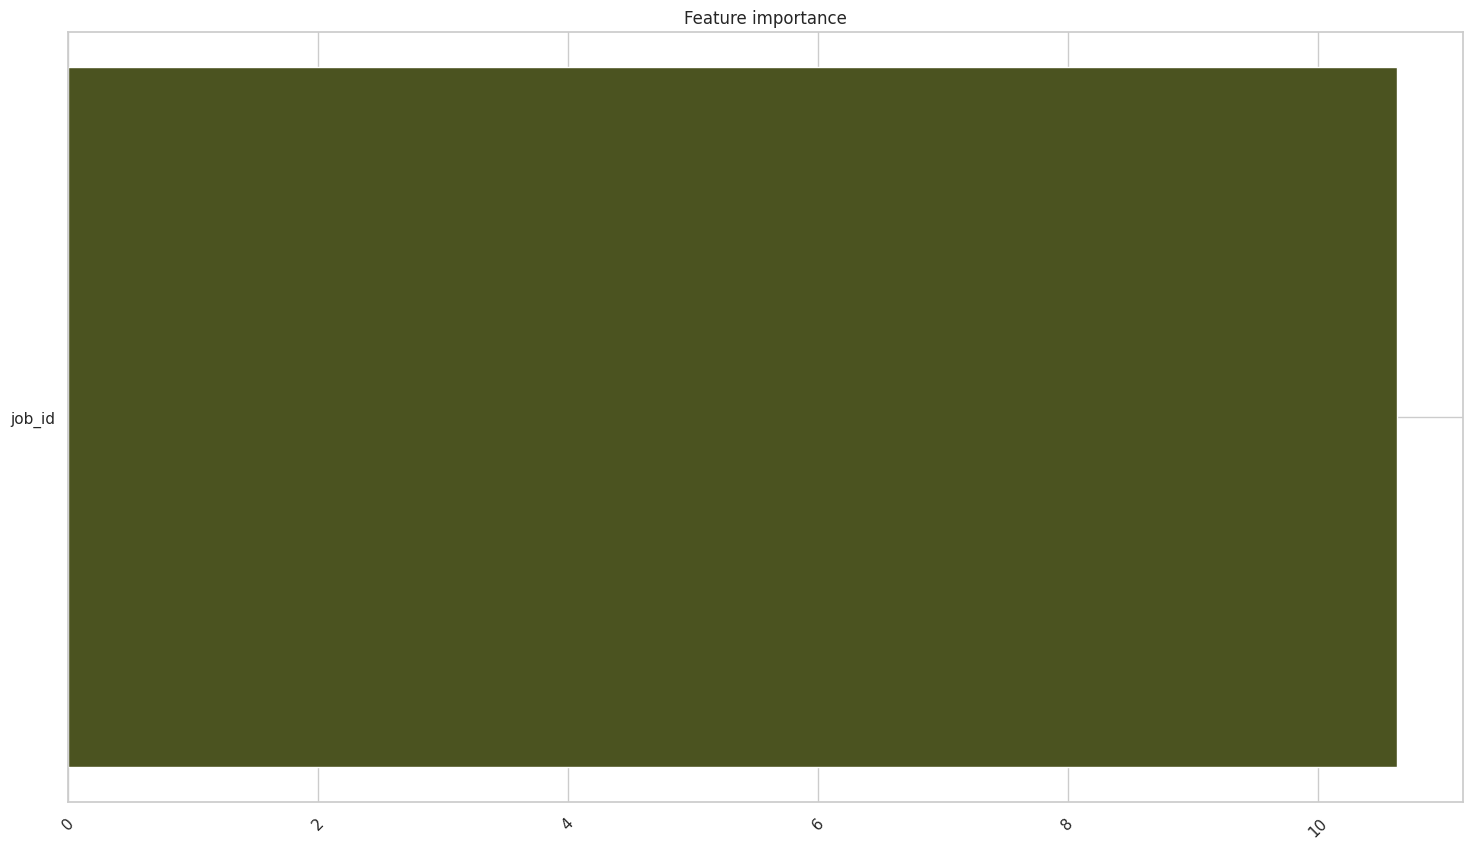

In [ ]:
feature_dict=dict(zip((df.columns),list(model_rfm.feature_importances_)))

log_val=[]
for i in feature_dict.values():
  log_val.append(np.log(i))

log_val=np.nan_to_num(log_val,neginf=0)
log_val=[i*(-1) for i in log_val]
names=list(feature_dict.keys())
dictionary=dict(zip(names,log_val))

sorted_dict=dict(sorted(dictionary.items(),key=lambda x:x[1],reverse=True))
names=[]
values=[]
for k,v in sorted_dict.items():
  if v != -0.0:
    names.append(k)
    values.append(v)

plt.figure(figsize=(18,10))
colors=["#4b5320"]
plt.barh(range(len(values)),values,tick_label=names,color=colors[0])
plt.xticks(rotation=45)
plt.title('Feature importance')
plt.show()

Using Naive Bayes

In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/content/sample_data/fake_job_postings.csv'):
  for filename in filenames:
    print(os.path.join(dirname, filename))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import string

In [ ]:
data=pd.read_csv('/content/sample_data/fake_job_postings.csv')

In [ ]:
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [ ]:
data.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
data.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [ ]:
data.drop(['job_id','salary_range','telecommuting','has_company_logo','has_questions'],axis=1,inplace=True)

In [ ]:
data.head()

,title,location,department,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
data.shape

(17880, 13)

In [ ]:
data.fillna('',inplace=True)

In [ ]:
data.isnull().sum()

,0
title,0
location,0
department,0
company_profile,0
description,0
requirements,0
benefits,0
employment_type,0
required_experience,0
required_education,0


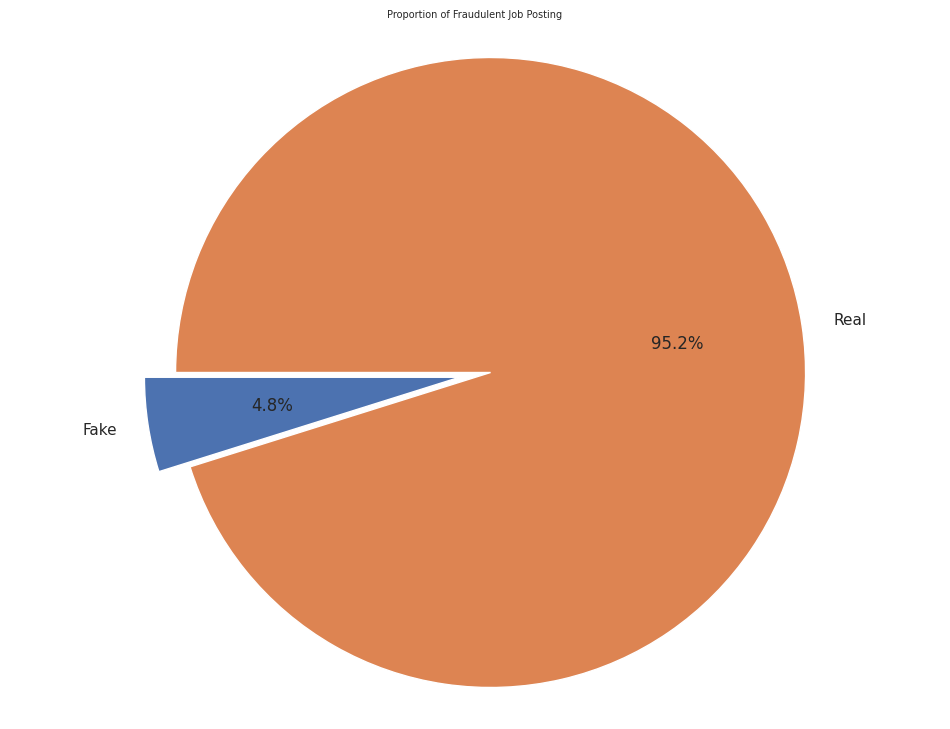

In [ ]:
labels='Fake','Real'

sizes=[data.fraudulent[data['fraudulent']==1].count(),data.fraudulent[data['fraudulent']==0].count()]
explode=(0,0.1)

figl,axl=plt.subplots(figsize=(12,9))
axl.pie(sizes,explode=explode,labels=labels,autopct='%1.1f%%',startangle=180)

axl.axis('equal')
plt.title("Proportion of Fraudulent Job Posting",size=7)
plt.show()

In [ ]:
# Visualize job postings by countries

def split(location):
  l=location.split(',')
  return l[0]

data['country']=data.location.apply(split)

In [ ]:
data['country'].nunique()

91

In [ ]:
data['country'].value_counts()[:11]

,count
country,
US,10656
GB,2384
GR,940
CA,457
DE,383
,346
NZ,333
IN,276
AU,214


Text(0, 0.5, 'Number of Jobs')

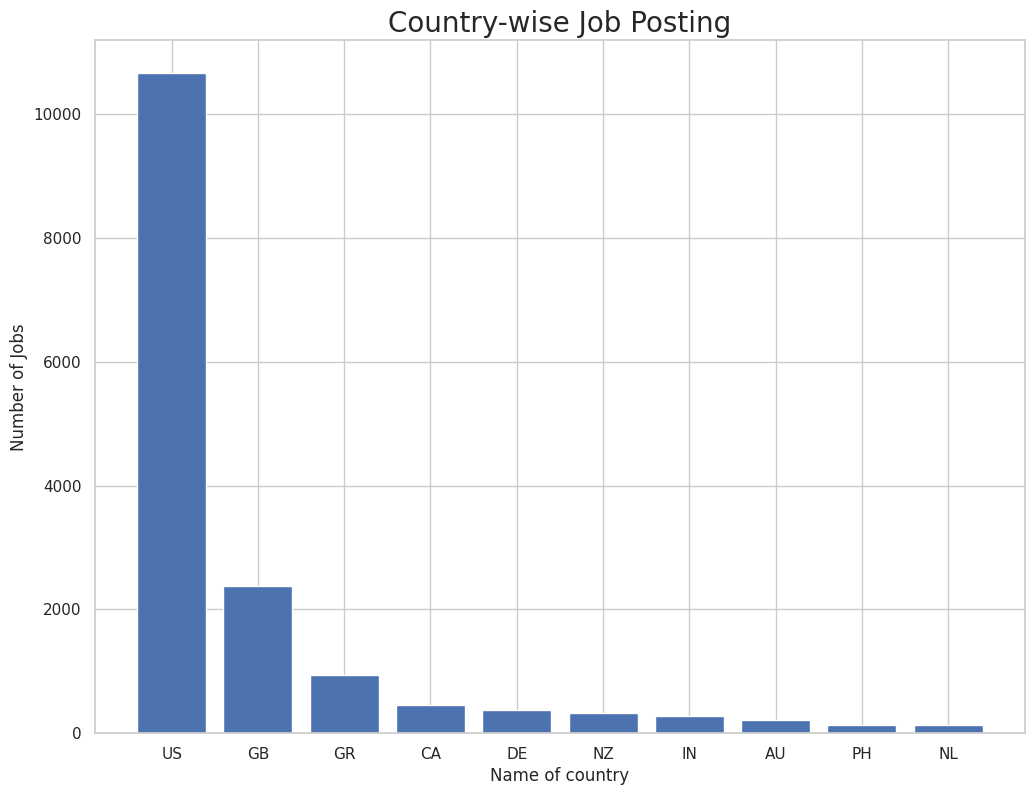

In [ ]:
country=dict(data.country.value_counts()[:11])

del country['']
plt.figure(figsize=(12,9))

plt.title('Country-wise Job Posting',size=20)
plt.bar(country.keys(),country.values())

plt.xlabel('Name of country')
plt.ylabel('Number of Jobs')

Text(0, 0.5, 'Number of Jobs')

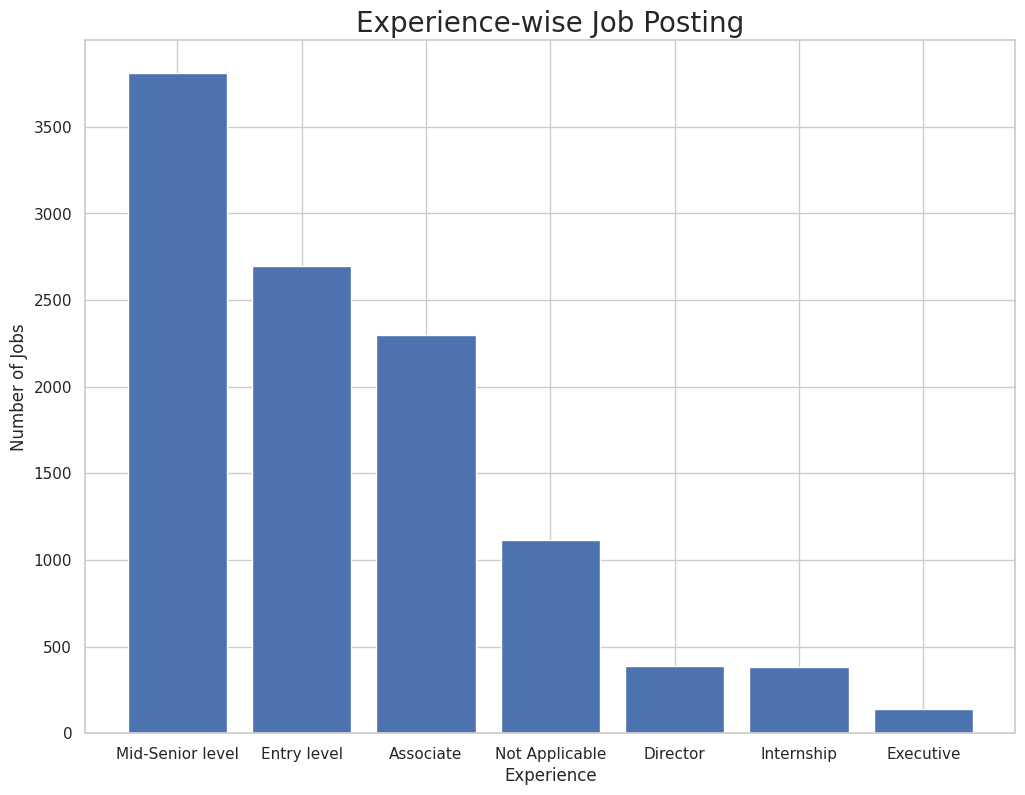

In [ ]:
# Visualize Job posting by experience

experience=dict(data.required_experience.value_counts())
del experience['']
plt.figure(figsize=(12,9))

plt.title('Experience-wise Job Posting',size=20)
plt.bar(experience.keys(),experience.values())

plt.xlabel('Experience')
plt.ylabel('Number of Jobs')

Text(0, 0.5, 'Number of Jobs')

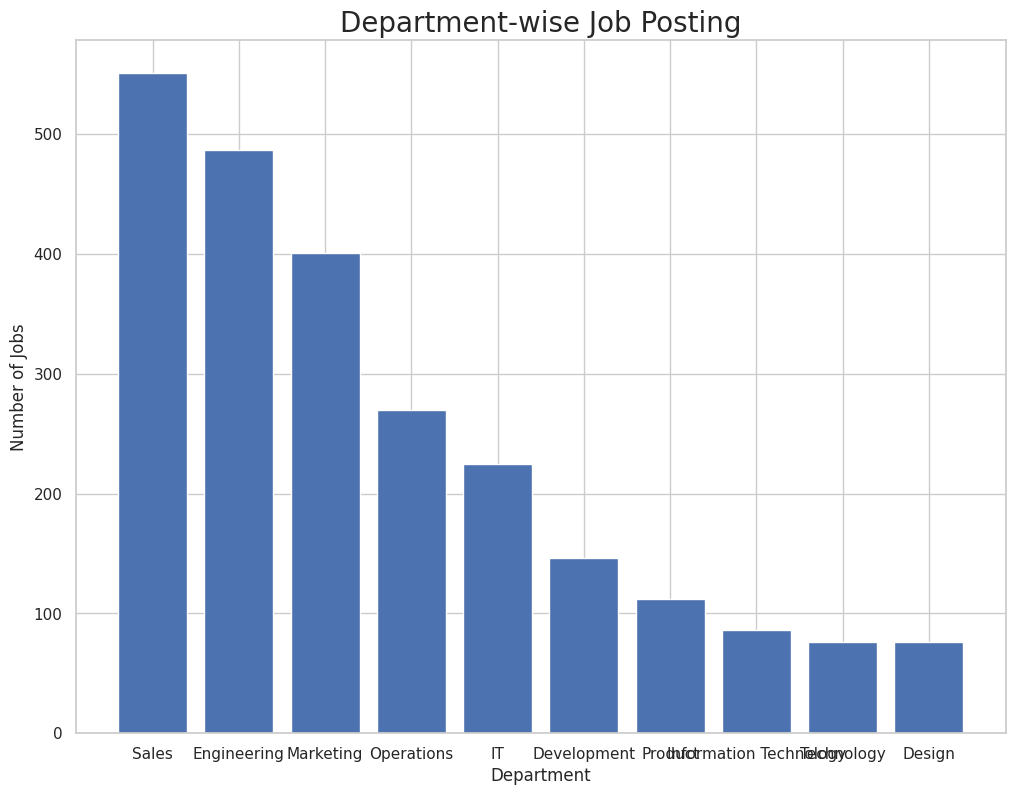

In [ ]:
# Visualize Job posting by department

department1=dict(data.department.value_counts()[:11])
del department1['']
plt.figure(figsize=(12,9))

plt.title('Department-wise Job Posting',size=20)
plt.bar(department1.keys(),department1.values())

plt.xlabel('Department')
plt.ylabel('Number of Jobs')

In [ ]:
# To find the fake job titles

data.title.value_counts()[:11]

,count
title,
English Teacher Abroad,311
Customer Service Associate,146
Graduates: English Teacher Abroad (Conversational),144
English Teacher Abroad,95
Software Engineer,86
English Teacher Abroad (Conversational),83
Customer Service Associate - Part Time,76
Account Manager,75
Web Developer,66


In [ ]:
data[data.fraudulent==1].title.value_counts()[:11]

,count
title,
Data Entry Admin/Clerical Positions - Work From Home,21
Cruise Staff Wanted *URGENT*,21
Home Based Payroll Typist/Data Entry Clerks Positions Available,21
Customer Service Representative,17
Administrative Assistant,16
Home Based Payroll Data Entry Clerk Position - Earn $100-$200 Daily,12
"Account Sales Managers $80-$130,000/yr",10
Payroll Data Coordinator Positions - Earn $100-$200 Daily,10
Network Marketing,10


In [ ]:
data[data.fraudulent==0].title.value_counts()[:11]

,count
title,
English Teacher Abroad,311
Customer Service Associate,146
Graduates: English Teacher Abroad (Conversational),144
English Teacher Abroad,95
Software Engineer,86
English Teacher Abroad (Conversational),83
Customer Service Associate - Part Time,76
Account Manager,73
Web Developer,66


In [ ]:
data.columns

Index(['title', 'location', 'department', 'company_profile', 'description',
       'requirements', 'benefits', 'employment_type', 'required_experience',
       'required_education', 'industry', 'function', 'fraudulent', 'country'],
      dtype='object')

In [ ]:
data['text']=data['title']+' '+data['location']+' '+data['department']+' '+data['company_profile']+' '+data['description']

del data['title']
del data['location']
del data['department']
del data['company_profile']
del data['description']
del data['requirements']
del data['benefits']
del data['employment_type']
del data['required_experience']
del data['required_education']
del data['industry']
del data['function']

In [ ]:
data.head()

,fraudulent,country,text
0,0,US,"Marketing Intern US, NY, New York Marketing We..."
1,0,NZ,"Customer Service - Cloud Video Production NZ, ..."
2,0,US,"Commissioning Machinery Assistant (CMA) US, IA..."
3,0,US,"Account Executive - Washington DC US, DC, Wash..."
4,0,US,"Bill Review Manager US, FL, Fort Worth SpotSo..."


In [ ]:
# Check the frequency of word in datasets

from wordcloud import WordCloud
all_words=''.join([text for text in data['text']])

In [ ]:
wordcloud=WordCloud(width=600,height=300,max_font_size=120).generate(all_words)

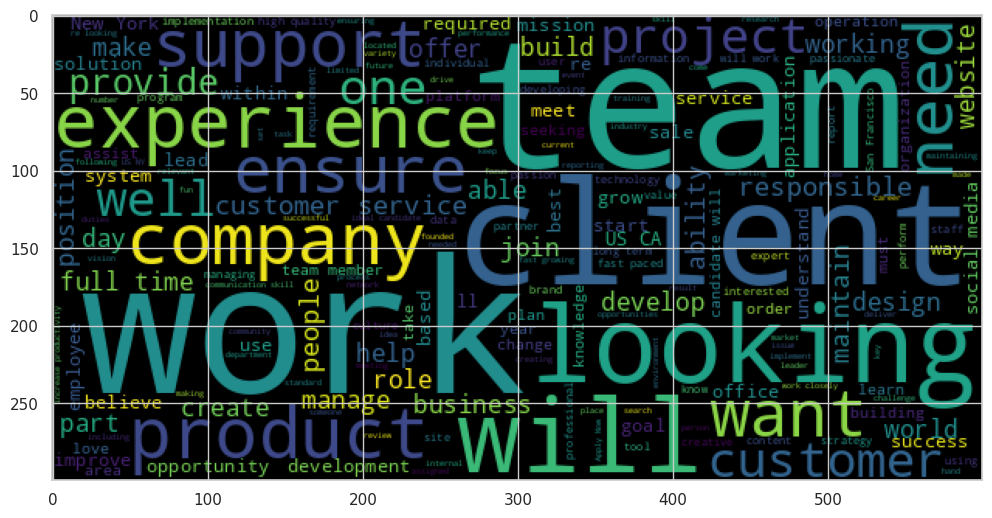

In [ ]:
plt.figure(figsize=(12,9))
plt.imshow(wordcloud)
plt.show()

In [ ]:
# Frequency of word in real posting of jobs
real_post=''.join([text for text in data['text'][data['fraudulent']==0]])

In [ ]:
wordcloud1=WordCloud(width=600,height=300,max_font_size=120).generate(real_post)

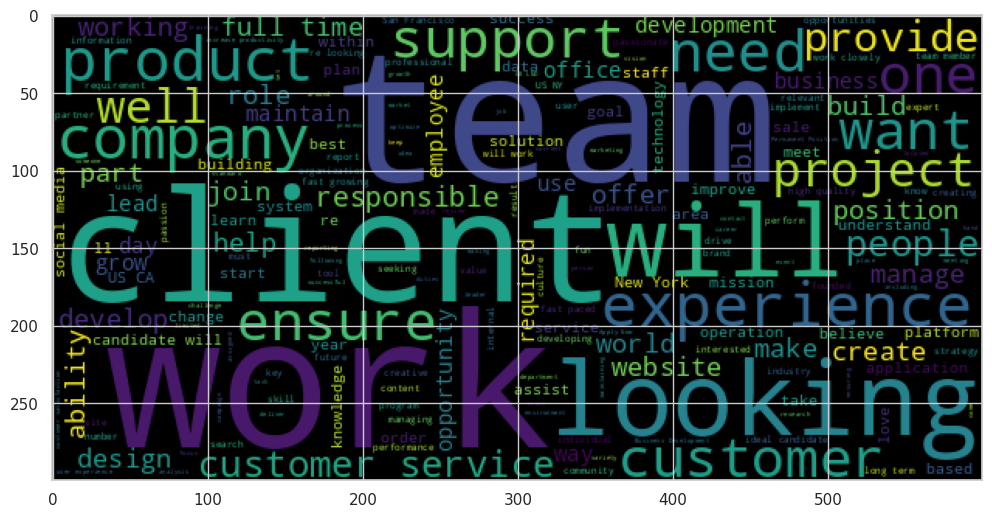

In [ ]:
plt.figure(figsize=(12,9))
plt.imshow(wordcloud1)
plt.show()

In [ ]:
# Frequency of word in fake job postings
fake_post=''.join([text for text in data['text'][data['fraudulent']==1]])

In [ ]:
wordcloud2=WordCloud(width=600,height=300,max_font_size=120).generate(fake_post)

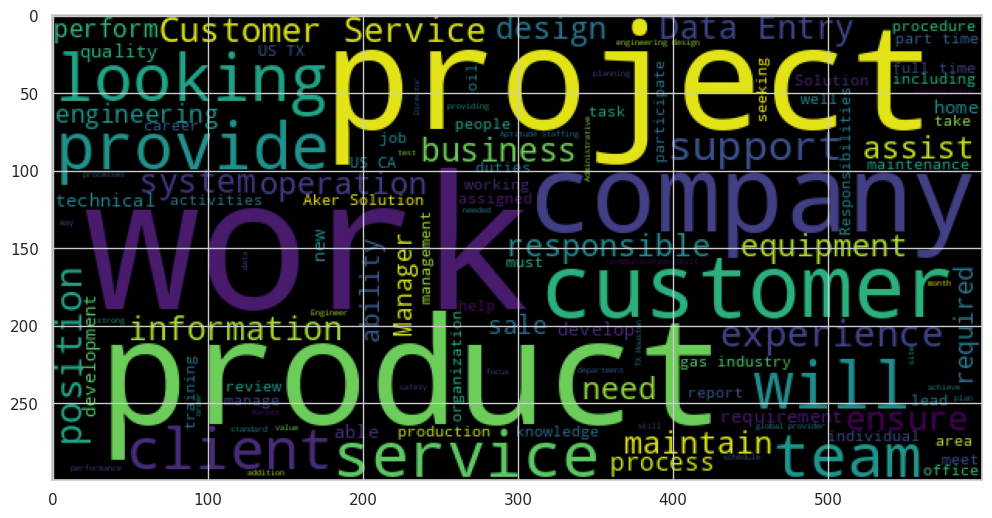

In [ ]:
plt.figure(figsize=(12,9))
plt.imshow(wordcloud2)
plt.show()

In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
stop_words=set(stopwords.words('english'))

In [ ]:
data['text']=data["text"].apply(lambda x:x.lower())

In [ ]:
data['text']=data['text'].apply(lambda x:''.join([word for word in x.split() if word not in(stop_words)]))

In [ ]:
data['text'][0]

"marketinginternus,ny,newyorkmarketingfood52,createdgroundbreakingaward-winningcookingsite.support,connect,celebratehomecooks,giveeverythingneedoneplace.wetopeditorial,business,engineeringteam.focusedusingtechnologyfindnewbetterwaysconnectpeoplearoundspecificfoodinterests,offersuperb,highlycuratedinformationfoodcooking.attracttalentedhomecookscontributorscountry;alsopublishwell-knownprofessionalslikemariobatali,gwynethpaltrow,dannymeyer.partnershipswholefoodsmarketrandomhouse.food52namedbestfoodwebsitejamesbeardfoundationiacp,featurednewyorktimes,npr,pandodaily,techcrunch,todayshow.we'relocatedchelsea,newyorkcity.food52,fast-growing,jamesbeardaward-winningonlinefoodcommunitycrowd-sourcedcuratedrecipehub,currentlyinterviewingfull-part-timeunpaidinternsworksmallteameditors,executives,developersnewyorkcityheadquarters.reproducingand/orrepackagingexistingfood52contentnumberpartnersites,huffingtonpost,yahoo,buzzfeed,variouscontentmanagementsystemsresearchingblogswebsitesprovisionsfood52affi

Using decision tree

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(data.text,data.fraudulent,test_size=0.3)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
vect = CountVectorizer()
vect.fit(x_train)

CountVectorizer()

In [ ]:
# Convert the text data into vector format
x_train_dtm=vect.transform(x_train)

In [ ]:
x_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 519606 stored elements and shape (12516, 190064)>

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
x_test_dtm=vect.transform(x_test)
x_test

,text
17688,"userexperiencedesigner|mobilein,ap,hyderabadus..."
8597,"manager,perioperativeservicesus,wa,findjobs#ur..."
13397,"qaengineergb,lnd,londonlaunched2010,lystinnova..."
3927,"marketingofficerca,bc,vancouvermarketingdepart..."
1047,"linuxserveradministratorin,mp,indoreserveradmi..."
...,...
11973,"asp.netdeveloperjobopportunityunitedstates,new..."
6108,"lombarditechnicalarchitectus,ca,sanfranciscopo..."
10823,"outsidesalesprofessional-livoniaus,mi,livoniaa..."
10773,"customerserviceassociateus,ca,newarknovitexent..."


In [ ]:
# Naive Bayes Classifier

nbinomial=MultinomialNB()
nbinomial.fit(x_train_dtm,y_train)

MultinomialNB()

In [ ]:
y_pred_nb=nbinomial.predict(x_test_dtm)

In [ ]:
accuracy_score(y_test,y_pred_nb)

0.9727815063385533

In [ ]:
# Decision Tree Classifier

dt=DecisionTreeClassifier()
dt.fit(x_train_dtm,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt=dt.predict(x_test_dtm)

In [ ]:
accuracy_score(y_test,y_pred_dt)

0.9809843400447428

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

In [ ]:
y=data.fraudulent
print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: fraudulent, dtype: int64


In [ ]:
x = data.drop('fraudulent', axis=1)
print(x.head())

  country                                               text
0      US  marketinginternus,ny,newyorkmarketingfood52,cr...
1      NZ  customerservice-cloudvideoproductionnz,,auckla...
2      US  commissioningmachineryassistant(cma)us,ia,weve...
3      US  accountexecutive-washingtondcus,dc,washingtons...
4      US  billreviewmanagerus,fl,fortworthspotsourcesolu...


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=4)
print('Train set:',x_train.shape, y_train.shape)
print('Test set:',x_test.shape, y_test.shape)

Train set: (12516, 2) (12516,)
Test set: (5364, 2) (5364,)


In [ ]:
input_text=['general laborers us, ct, hartford elite environmental group llc. provides staffing services temporary employment opportuinity']

In [ ]:
input_data=vect.transform(input_text)

prediction = dt.predict(input_data)

if(prediction[0]==1):
  print("This advertisement belonging to fake job post category")
else:
  print("This advertisement belonging to real job post category")

This advertisement belonging to real job post category


In [ ]:
input_text=['Data Entry Admin/Clerical Positions - Work From Home']

In [ ]:
input_data=vect.transform(input_text)

prediction = dt.predict(input_data)

if(prediction[0]==1):
  print("This advertisement belonging to fake job post category")
else:
  print("This advertisement belonging to real job post category")

This advertisement belonging to real job post category
